In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))


# فصل ۷ — ماشین‌های بردار پشتیبان (SVM)
## درس ۶: صورت‌بندی ریاضی مسئلهٔ بهینه‌سازی SVM


### اهداف یادگیری

در پایان این درس قادر خواهید بود:

- مسئلهٔ پرایمال SVM با **حاشیهٔ سخت (hard-margin)** را از اصول هندسی استخراج کنید.
- آن را به SVM با **حاشیهٔ نرم (soft-margin)** با استفاده از متغیرهای شُل (slack) تعمیم دهید و نقش **$C$** را توضیح دهید.
- صورت **دوآل** را با لاگرانژ و **شرایط KKT** (ایستایی، امکان‌پذیری، شلی مکمل) استخراج کنید.
- توضیح دهید چرا پاسخ فقط به **بردارهای پشتیبان (support vectors)** وابسته است (خاصیت تنکی).
- درک کنید چگونه **کرنل‌ها (kernels)** به‌صورت طبیعی در فرمول‌بندی دوآل ظاهر می‌شوند.
- (۱) یک بهینه‌ساز پرایمال برای **hinge loss** و (۲) یک حل‌گر دوآل **SMO-like** (از صفر، آموزشی) پیاده‌سازی کنید.
- نتایج را با `scikit-learn` اعتبارسنجی کنید و حساسیت به $C$ و کرنل‌ها را بررسی کنید.

---

### نمادگذاری

فرض می‌کنیم یک دیتاست طبقه‌بندی دودویی $\{(x_i, y_i)\}_{i=1}^n$ داریم که:

- $x_i \in \mathbb{R}^d$
- $y_i \in \{-1, +1\}$

یک طبقه‌بند خطی با $(w, b)$ پارامتردهی می‌شود و تابع تصمیم:

$$
f(x) = w^\top x + b,
\qquad \hat{y} = \mathrm{sign}(f(x)).
$$

بین این دو مفهوم تمایز می‌گذاریم:

- **حاشیهٔ تابعی**: $y_i(w^\top x_i + b)$
- **حاشیهٔ هندسی**: $\dfrac{y_i(w^\top x_i + b)}{\|w\|_2}$

SVM حاشیهٔ هندسی را بیشینه می‌کند (یا معادل آن، تحت قیود کانونی $\|w\|_2$ را کمینه می‌کند).


### هندسهٔ طبقه‌بندی با بیشترین حاشیه (شهود)

```mermaid
flowchart TD
    A["Training data: (x_i, y_i)"] --> B["Choose linear decision boundary"]
    B --> C["Impose canonical constraints: y_i(w^T x_i + b) >= 1"]
    C --> D["Margin becomes 1/||w||"]
    D --> E["Minimize 0.5||w||^2"]
    E --> F["Only support vectors have alpha_i > 0"]
```

## ۱) SVM با حاشیهٔ سخت: از هندسه تا بهینه‌سازی محدب

فرض کنید داده‌ها **خطی‌قابل‌جداسازی** هستند.

### ۱.۱ فاصلهٔ یک نقطه تا ابرصفحه (استخراج)

ابرصفحه را $\mathcal{H} = \{x : w^\top x + b = 0\}$ در نظر بگیرید که $w \neq 0$.

نزدیک‌ترین نقطهٔ روی ابرصفحه به $x_0$:

$$
x^\star = x_0 - \frac{w^\top x_0 + b}{\|w\|_2^2} w.
$$

پس فاصله:

$$
\mathrm{dist}(x_0, \mathcal{H})
= \|x_0 - x^\star\|_2
= \frac{|w^\top x_0 + b|}{\|w\|_2}.
$$

### ۱.۲ حاشیهٔ هندسی

برای $(x_i,y_i)$:

$$
\gamma_i = \frac{y_i(w^\top x_i + b)}{\|w\|_2},
\qquad
\gamma = \min_i \gamma_i.
$$

هدف: بیشینه‌سازی $\gamma$.

### ۱.۳ قیود کانونی و ناوردایی مقیاس

به‌علت ناوردایی نسبت به مقیاس، قید کانونی می‌گذاریم:

$$
y_i(w^\top x_i + b) \ge 1\ \forall i.
$$

در این صورت:

$$
\gamma = \frac{1}{\|w\|_2}.
$$

پس بیشینه‌سازی حاشیه معادل کمینه‌سازی $\|w\|_2$ است.

### ۱.۴ پرایمال حاشیهٔ سخت

$$
\min_{w,b}\ \frac{1}{2}\|w\|_2^2
\quad\text{s.t.}\quad
y_i(w^\top x_i + b) \ge 1,\ \forall i.
$$

### ۱.۵ محدب‌بودن و یکتایی

تابع هدف نسبت به $w$ به‌شدت محدب است و قیود آفین‌اند؛ بنابراین مسئله محدب است و پاسخ $w$ یکتا خواهد بود.


## ۲) SVM با حاشیهٔ نرم: slack و hinge loss

برای داده‌های غیرقابل‌جداسازی، متغیرهای شُل $\xi_i \ge 0$ معرفی می‌کنیم:

$$
y_i(w^\top x_i + b) \ge 1 - \xi_i,\qquad \xi_i \ge 0.
$$

پرایمال حاشیهٔ نرم:

$$
\min_{w,b,\xi}\ \frac12\|w\|_2^2 + C\sum_i \xi_i
\quad\text{s.t.}\quad
y_i(w^\top x_i + b) \ge 1 - \xi_i,\ \xi_i \ge 0.
$$

hinge loss:

$$
\ell_{\mathrm{hinge}}(y,f(x)) = \max(0,\ 1 - y f(x)).
$$

برای $(w,b)$ ثابت، کوچک‌ترین $\xi_i$ مجاز برابر است با:

$$
\xi_i^\star = \max(0, 1 - y_i(w^\top x_i + b)).
$$

با جایگذاری، فرم بدون قید hinge loss به‌دست می‌آید.

### نقش $C$

- $C$ بزرگ: نقض‌ها جریمهٔ زیاد دارند.
- $C$ کوچک: منظم‌سازی بیشتر و تحمل نقض‌ها.


## ۳) استخراج دوآل با لاگرانژ و KKT (گسترش‌یافته)

قیود را به‌شکل زیر می‌نویسیم:

$$
1 - \xi_i - y_i(w^\top x_i + b) \le 0,\qquad -\xi_i \le 0.
$$

ضرایب $\alpha_i \ge 0$ و $\mu_i \ge 0$ را معرفی می‌کنیم و لاگرانژین:

$$
\mathcal{L}
=
\frac12\|w\|_2^2 + C\sum_i \xi_i
+ \sum_i \alpha_i\bigl(1 - \xi_i - y_i(w^\top x_i + b)\bigr)
+ \sum_i \mu_i(-\xi_i).
$$

### ۳.۱ ایستایی

با صفر کردن مشتق‌ها:

$$
w = \sum_i \alpha_i y_i x_i,
\qquad
\sum_i \alpha_i y_i = 0,
\qquad
\alpha_i + \mu_i = C \Rightarrow 0\le \alpha_i \le C.
$$

### ۳.۲ دوآل

با جایگذاری $w$، دوآل:

$$
\max_{\alpha}\ 
\sum_i \alpha_i
- \frac12\sum_i\sum_j \alpha_i\alpha_j y_i y_j x_i^\top x_j
\quad\text{s.t.}\quad
0\le \alpha_i \le C,\ \sum_i \alpha_i y_i = 0.
$$

### ۳.۳ بردار پشتیبان

به‌علت رابطهٔ $w = \sum_i \alpha_i y_i x_i$، فقط نقاطی که $\alpha_i>0$ دارند در مدل حضور دارند؛ این‌ها همان بردارهای پشتیبان‌اند.


## ۴) کرنل‌سازی

در دوآل فقط ضرب داخلی‌ها $x_i^\top x_j$ ظاهر می‌شود. آن را با کرنل جایگزین کنید:

$$
K(x_i, x_j) = \phi(x_i)^\top \phi(x_j).
$$

دوآل کرنلی:

$$
\max_{\alpha}\ 
\sum_i \alpha_i
- \frac12\sum_i\sum_j \alpha_i\alpha_j y_i y_j K(x_i,x_j)
\quad\text{s.t.}\quad
0\le \alpha_i \le C,\ \sum_i \alpha_i y_i = 0.
$$

تابع تصمیم:

$$
f(x) = \sum_i \alpha_i y_i K(x_i,x) + b.
$$

کرنل معتبر باید Gram را PSD کند (در کد به‌صورت عددی بررسی می‌کنیم).


## ۵) آزمایش‌های عملی (دو دیتاست تصادفی)

در ادامه:

- SVM خطی مرجع (`scikit-learn`) را اجرا می‌کنیم،
- پهنای حاشیه را در حالت خطی با $2/\|w\|_2$ محاسبه می‌کنیم،
- با PCA یک تصویرسازی دوبعدی انجام می‌دهیم،
- حل‌گر SGD پرایمال hinge loss (آموزشی) را اجرا می‌کنیم،
- حل‌گر SMO-like دوآل (آموزشی) را اجرا می‌کنیم،
- اثر $C$ و تفاوت خطی و RBF را بررسی می‌کنیم،
- و همین روند را روی دیتاست تصادفی دوم هم یک بار سریع تکرار می‌کنیم.

نکتهٔ مهم: همهٔ سلول‌های کد (از جمله عنوان نمودارها، برچسب‌ها، legend و توضیحات داخل کد) انگلیسی باقی مانده‌اند.


In [2]:
import numpy as np
import pandas as pd

# Choose datasets *randomly* (but reproducibly) from your Classification datasets.
# We will use more than one dataset in this lesson.
rng = np.random.default_rng(7)

candidates = [
    ("../../../Datasets/Classification/diabetes.csv", "classification"),
    ("../../../Datasets/Classification/drug200.csv", "Drug"),
    ("../../../Datasets/Classification/iris.csv", "classification"),
    ("../../../Datasets/Classification/glass.csv", "Type"),
    ("../../../Datasets/Classification/Wine_Quality.csv", "quality"),
    ("../../../Datasets/Classification/stars.csv", "Type"),
]

chosen_main = candidates[int(rng.integers(0, len(candidates)))]
chosen_secondary = candidates[int(rng.integers(0, len(candidates)))]
while chosen_secondary == chosen_main:
    chosen_secondary = candidates[int(rng.integers(0, len(candidates)))]

chosen_main, chosen_secondary


(('../../../Datasets/Classification/stars.csv', 'Type'),
 ('../../../Datasets/Classification/glass.csv', 'Type'))

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

def make_binary_problem(df, target_col):
    # Convert an arbitrary target column to a binary task with y in {-1, +1}.
    y = df[target_col]
    X = df.drop(columns=[target_col])

    # Categorical target: take the 2 most frequent classes
    if y.dtype == object:
        vc = y.value_counts()
        classes = vc.index[:2].tolist()
        mask = y.isin(classes)
        Xb = X.loc[mask].copy()
        yb = y.loc[mask].copy()
        y_bin = np.where(yb == classes[0], 1, -1)
        info = {"type": "categorical", "classes_used": classes, "mapping": {classes[0]: 1, classes[1]: -1}}
        return Xb, y_bin, info

    # Numeric target: threshold at median
    thr = float(y.median())
    y_bin = np.where(y >= thr, 1, -1)
    info = {"type": "numeric_threshold", "threshold": thr, "rule": "y>=threshold -> +1 else -1"}
    return X.copy(), y_bin, info

def load_or_fallback(path, target_col):
    try:
        df = pd.read_csv(path)
        return df, target_col, path
    except FileNotFoundError:
        # Fallback if running outside your repo
        from sklearn.datasets import load_breast_cancer
        bc = load_breast_cancer(as_frame=True)
        df = bc.frame.rename(columns={"target":"target"})
        return df, "target", "sklearn.datasets.load_breast_cancer()"

rel_path, target_col = chosen_main
df, target_col, source = load_or_fallback(rel_path, target_col)

X, y, info = make_binary_problem(df, target_col)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("scaler", StandardScaler())]), num_cols),
        ("cat", Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ],
    remainder="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y if len(np.unique(y))==2 else None
)

print("Main dataset source:", source)
print("Binary task info:", info)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))


Main dataset source: ../../../Datasets/Classification/stars.csv
Binary task info: {'type': 'categorical', 'classes_used': ['Red Dwarf', 'Brown Dwarf'], 'mapping': {'Red Dwarf': 1, 'Brown Dwarf': -1}}
Train shape: (60, 6) Test shape: (20, 6)
Numeric cols: 4 Categorical cols: 2


In [4]:
from sklearn.svm import SVC

clf = Pipeline([
    ("prep", preprocess),
    ("svm", SVC(kernel="linear", C=1.0))
])

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(classification_report(y_test, pred))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))

svm_model = clf.named_steps["svm"]
print("n_support_:", svm_model.n_support_)
print("Total support vectors:", int(np.sum(svm_model.n_support_)))


              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Confusion matrix:
 [[10  0]
 [ 0 10]]
n_support_: [3 4]
Total support vectors: 7


In [5]:
# Extract w and b for linear kernel (fit on transformed features to access coef_ reliably)
import numpy as np

Xtr = preprocess.fit_transform(X_train)
Xte = preprocess.transform(X_test)

svm_raw = SVC(kernel="linear", C=1.0)
svm_raw.fit(Xtr, y_train)

w = svm_raw.coef_.ravel()
b = float(svm_raw.intercept_[0])

w_norm = np.linalg.norm(w)
margin_width = 2.0 / w_norm

print("||w||_2 =", w_norm)
print("Margin width 2/||w|| =", margin_width)
print("b =", b)


||w||_2 = 1.9789217823138394
Margin width 2/||w|| = 1.0106513647353534
b = -0.2737085649146744


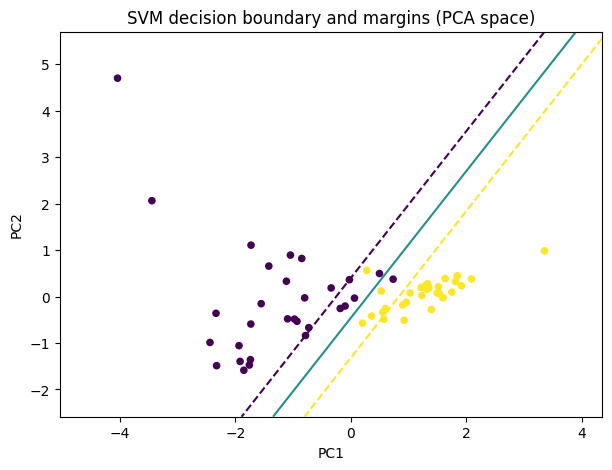

Support vectors in PCA space: 13


In [6]:
# Visualize in 2D via PCA (visual aid)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

Xtr_dense = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
Xte_dense = Xte.toarray() if hasattr(Xte, "toarray") else Xte

pca = PCA(n_components=2, random_state=0)
Xtr2 = pca.fit_transform(Xtr_dense)
Xte2 = pca.transform(Xte_dense)

svm2 = SVC(kernel="linear", C=1.0)
svm2.fit(Xtr2, y_train)

x_min, x_max = Xtr2[:,0].min()-1, Xtr2[:,0].max()+1
y_min, y_max = Xtr2[:,1].min()-1, Xtr2[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = svm2.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contour(xx, yy, Z, levels=[-1,0,1], linestyles=["--","-","--"])
plt.scatter(Xtr2[:,0], Xtr2[:,1], c=y_train, s=20)
plt.title("SVM decision boundary and margins (PCA space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Support vectors in PCA space:", svm2.support_vectors_.shape[0])


In [7]:
# Primal hinge-loss optimization via mini-batch SGD (educational)
import numpy as np
from sklearn.metrics import classification_report

def hinge_loss(y, scores):
    return np.maximum(0.0, 1.0 - y * scores)

def train_primal_hinge_sgd(X, y, C=1.0, lr=0.01, epochs=80, batch_size=64, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    history = []
    for ep in range(epochs):
        idx = rng.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start+batch_size]
            Xb = X[batch]
            yb = y[batch]
            scores = Xb @ w + b
            margin = yb * scores
            active = margin < 1.0
            grad_w = w + C * (-(yb[active, None] * Xb[active]).sum(axis=0))
            grad_b = C * (-(yb[active]).sum())
            w -= lr * grad_w
            b -= lr * grad_b
        obj = 0.5 * np.dot(w,w) + C * hinge_loss(y, X @ w + b).sum()
        history.append(obj)
    return w, b, np.array(history)

w_sgd, b_sgd, hist = train_primal_hinge_sgd(Xtr_dense, y_train, C=1.0, lr=0.01, epochs=80, batch_size=64, seed=0)
pred_sgd = np.sign(Xte_dense @ w_sgd + b_sgd)
pred_sgd[pred_sgd==0] = 1

print(classification_report(y_test, pred_sgd))


              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



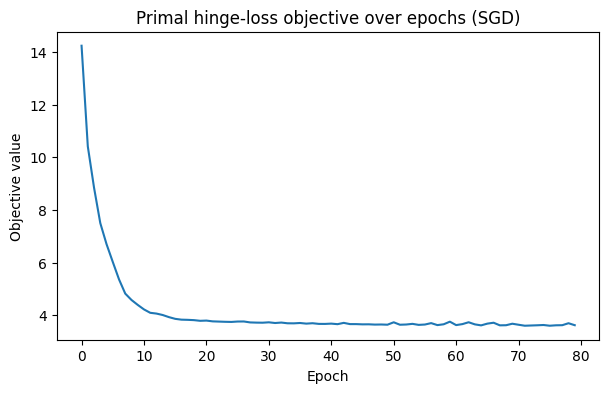

||w_sgd||_2 = 1.946936693397566


In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,4))
plt.plot(hist)
plt.title("Primal hinge-loss objective over epochs (SGD)")
plt.xlabel("Epoch")
plt.ylabel("Objective value")
plt.show()

print("||w_sgd||_2 =", np.linalg.norm(w_sgd))


In [9]:
# Simplified SMO-like dual solver for linear SVM (educational)
import numpy as np

def linear_kernel_matrix(X):
    return X @ X.T

def smo_train_linear(X, y, C=1.0, tol=1e-3, max_passes=12, seed=0):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    alpha = np.zeros(n)
    b = 0.0
    K = linear_kernel_matrix(X)

    def f(i):
        return (alpha * y) @ K[:, i] + b

    passes = 0
    while passes < max_passes:
        num_changed = 0
        for i in range(n):
            Ei = f(i) - y[i]
            if (y[i]*Ei < -tol and alpha[i] < C) or (y[i]*Ei > tol and alpha[i] > 0):
                j = int(rng.integers(0, n-1))
                if j >= i:
                    j += 1
                Ej = f(j) - y[j]

                ai_old, aj_old = alpha[i], alpha[j]

                if y[i] != y[j]:
                    L = max(0.0, aj_old - ai_old)
                    H = min(C, C + aj_old - ai_old)
                else:
                    L = max(0.0, ai_old + aj_old - C)
                    H = min(C, ai_old + aj_old)

                if abs(H - L) < 1e-12:
                    continue

                eta = 2*K[i,j] - K[i,i] - K[j,j]
                if eta >= 0:
                    continue

                aj_new = aj_old - y[j] * (Ei - Ej) / eta
                aj_new = np.clip(aj_new, L, H)

                if abs(aj_new - aj_old) < 1e-6:
                    continue

                ai_new = ai_old + y[i]*y[j]*(aj_old - aj_new)

                b1 = b - Ei - y[i]*(ai_new - ai_old)*K[i,i] - y[j]*(aj_new - aj_old)*K[i,j]
                b2 = b - Ej - y[i]*(ai_new - ai_old)*K[i,j] - y[j]*(aj_new - aj_old)*K[j,j]

                if 0 < ai_new < C:
                    b = b1
                elif 0 < aj_new < C:
                    b = b2
                else:
                    b = 0.5*(b1 + b2)

                alpha[i], alpha[j] = ai_new, aj_new
                num_changed += 1

        passes = passes + 1 if num_changed == 0 else 0

    return alpha, b

# Train on a subset if very large
nmax = 800
if Xtr_dense.shape[0] > nmax:
    idx = np.random.default_rng(0).choice(Xtr_dense.shape[0], size=nmax, replace=False)
    X_smo = Xtr_dense[idx]
    y_smo = y_train[idx]
else:
    X_smo = Xtr_dense
    y_smo = y_train

alpha_smo, b_smo = smo_train_linear(X_smo, y_smo, C=1.0, tol=1e-3, max_passes=12, seed=0)
w_smo = (alpha_smo * y_smo) @ X_smo

print("Nonzero alphas:", int(np.sum(alpha_smo > 1e-6)))
print("||w_smo||_2:", float(np.linalg.norm(w_smo)))


Nonzero alphas: 7
||w_smo||_2: 1.9547446960085137


In [10]:
# Evaluate SMO model on test set
from sklearn.metrics import classification_report
import numpy as np

scores = Xte_dense @ w_smo + b_smo
pred_smo = np.sign(scores)
pred_smo[pred_smo==0] = 1

print(classification_report(y_test, pred_smo))


              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [11]:
# Compare agreement between solvers
import numpy as np

def agreement(a, b):
    return float(np.mean(a == b))

pred_sklearn = np.sign(svm_raw.decision_function(Xte_dense))
pred_sklearn[pred_sklearn==0] = 1

print("Agreement (sklearn vs SGD):", agreement(pred_sklearn, pred_sgd))
print("Agreement (sklearn vs SMO):", agreement(pred_sklearn, pred_smo))

print("||w_sklearn||_2:", float(np.linalg.norm(w)))
print("||w_sgd||_2    :", float(np.linalg.norm(w_sgd)))
print("||w_smo||_2    :", float(np.linalg.norm(w_smo)))


Agreement (sklearn vs SGD): 1.0
Agreement (sklearn vs SMO): 1.0
||w_sklearn||_2: 1.9789217823138394
||w_sgd||_2    : 1.946936693397566
||w_smo||_2    : 1.9547446960085137


In [12]:
# Explore effect of C and also try a nonlinear kernel (RBF) for comparison
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

Cs = [0.05, 0.1, 1.0, 10.0]
rows = []

for C in Cs:
    model = SVC(kernel="linear", C=C)
    model.fit(Xtr_dense, y_train)
    pred = model.predict(Xte_dense)
    acc = accuracy_score(y_test, pred)
    w_norm = float(np.linalg.norm(model.coef_.ravel()))
    sv = int(model.support_.shape[0])
    rows.append((C, "linear", acc, sv, 2.0/w_norm))

for C in [0.1, 1.0]:
    model = SVC(kernel="rbf", C=C, gamma="scale")
    model.fit(Xtr_dense, y_train)
    pred = model.predict(Xte_dense)
    acc = accuracy_score(y_test, pred)
    sv = int(model.support_.shape[0])
    rows.append((C, "rbf", acc, sv, np.nan))

pd.DataFrame(rows, columns=["C", "kernel", "test_accuracy", "n_support_vectors", "margin_width(2/||w||)"])


,C,kernel,test_accuracy,n_support_vectors,margin_width(2/||w||)
0,0.05,linear,1.00,28,2.257313
1,0.10,linear,1.00,21,1.718917
2,1.00,linear,1.00,7,1.010651
3,10.00,linear,1.00,4,0.491251
4,0.10,rbf,0.95,51,NaN
5,1.00,rbf,1.00,19,NaN


In [13]:
# Secondary dataset quick check (uses a different random dataset path)
from sklearn.svm import SVC
from sklearn.metrics import classification_report

rel_path2, target_col2 = chosen_secondary
df2, target_col2, source2 = load_or_fallback(rel_path2, target_col2)

X2, y2, info2 = make_binary_problem(df2, target_col2)

num_cols2 = X2.select_dtypes(include=[np.number]).columns.tolist()
cat_cols2 = [c for c in X2.columns if c not in num_cols2]

preprocess2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("scaler", StandardScaler())]), num_cols2),
        ("cat", Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols2),
    ],
    remainder="drop",
)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42, stratify=y2 if len(np.unique(y2))==2 else None
)

X2tr = preprocess2.fit_transform(X2_train)
X2te = preprocess2.transform(X2_test)

X2tr_dense = X2tr.toarray() if hasattr(X2tr, "toarray") else X2tr
X2te_dense = X2te.toarray() if hasattr(X2te, "toarray") else X2te

svm2_model = SVC(kernel="linear", C=1.0)
svm2_model.fit(X2tr_dense, y2_train)
pred2 = svm2_model.predict(X2te_dense)

print("Secondary dataset source:", source2)
print("Binary task info:", info2)
print(classification_report(y2_test, pred2))
print("Support vectors:", svm2_model.support_.shape[0])


Secondary dataset source: ../../../Datasets/Classification/glass.csv
Binary task info: {'type': 'categorical', 'classes_used': ['building_windows_non_float_processed', 'building_windows_float_processed'], 'mapping': {'building_windows_non_float_processed': 1, 'building_windows_float_processed': -1}}
              precision    recall  f1-score   support

          -1       0.71      0.67      0.69        18
           1       0.70      0.74      0.72        19

    accuracy                           0.70        37
   macro avg       0.70      0.70      0.70        37
weighted avg       0.70      0.70      0.70        37

Support vectors: 71


In [14]:
# Kernel PSD sanity check (Gram matrix eigenvalues) on a small subset
import numpy as np

def rbf_kernel(X, gamma):
    Xn = np.sum(X*X, axis=1, keepdims=True)
    sqdist = Xn + Xn.T - 2*(X @ X.T)
    return np.exp(-gamma * sqdist)

subset = Xtr_dense[:250]
K_lin = subset @ subset.T
K_rbf = rbf_kernel(subset, gamma=1.0/subset.shape[1])

eig_lin = np.linalg.eigvalsh((K_lin + K_lin.T)/2)
eig_rbf = np.linalg.eigvalsh((K_rbf + K_rbf.T)/2)

print("Linear Gram min eigenvalue:", float(eig_lin.min()))
print("RBF Gram min eigenvalue:", float(eig_rbf.min()))


Linear Gram min eigenvalue: -2.8824129685215215e-14
RBF Gram min eigenvalue: 8.358756954777312e-08


## ۶) نمودار خلاصه: پرایمال در برابر دوآل

```mermaid
flowchart TB
    A[Soft-margin primal] --> B[Hinge-loss ERM form]
    A --> C[Lagrangian + KKT]
    C --> D[w = sum alpha_i y_i x_i]
    C --> E[0 <= alpha_i <= C, sum alpha_i y_i = 0]
    D --> F[Dual QP]
    F --> G[Kernel trick]
    F --> H[Support vectors: alpha_i > 0]
```


## ۷) تمرین‌ها و نکات تفسیر

۱) نشان دهید پهنای نوار حاشیه برابر $2/\|w\|_2$ است.  
۲) $C$ را روی چند مقدار مختلف جاروب کنید و تعداد SV را گزارش کنید.  
۳) خطی و RBF را مقایسه کنید و تغییر تعداد SV را تفسیر کنید.  
۴) توضیح دهید چرا بدون scaling نتایج SVM می‌تواند بی‌ثبات شود.

---

## منابع

Vapnik؛ Cortes & Vapnik (1995)؛ Boyd & Vandenberghe؛ Burges (1998)؛ Platt (1998).


## ضمیمهٔ A) نکات تکمیلی نظری

- در قیود کانونی، $\gamma = 1/\|w\|_2$ و پهنای نوار حاشیه $2/\|w\|_2$ است.  
- دوگانگی قوی برای SVM حاشیهٔ نرم برقرار است (شرط Slater معمولاً برقرار است).  
- PSD بودن کرنل برای پایدار بودن مسئلهٔ دوآل ضروری است.  
- خروجی SVM احتمال نیست و برای احتمال باید کالیبراسیون انجام شود.
